In [ ]:
import numpy as np
import umap
_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_circular_1.npz"
EMBEDDING_MODEL_PATH = "mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_1.pth"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]

umap_model = umap.UMAP(n_components=2, random_state=67)
umap_model.fit(_embeddings)

FileNotFoundError: [Errno 2] No such file or directory: 'mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_contrastive_6.npz'

In [ ]:
# Generate and evaluate 10 random tracks
import requests
import random

randomizer = random.Random(100)
num_tracks = 10
seed_candidates = randomizer.sample(range(1, 10000), num_tracks)

def generate_track(seed, randomizer):
    response = requests.post(
        "http://localhost:4242/generate",
        json={
            "id": seed,
            "mode": "voronoi",
            "trackSize": randomizer.randint(4, 10),
            "rngMode": 0,
        },
        timeout=60,
    )

    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    sol = response.json()
    sol["rngMode"] = 1
    return sol

def eval_track(sol):
    response = requests.post(
        "http://localhost:4242/evaluate",
        json=sol,
        timeout=60,
    )
    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    r_json = response.json()
    return r_json.get("fitness", {})

tracks_results = []
for seed in seed_candidates:
    try:
        sol = generate_track(seed, randomizer)
        fit = eval_track(sol)
        embedding_data = fit.get("embedding_data", [])

        if embedding_data is None or len(embedding_data) == 0:
            print(f"Seed {seed}: missing embedding_data, skipped")
            continue

        tracks_results.append({
            "seed": seed,
            "solution": sol,
            "fitness": fit,
            "embedding_data": embedding_data,
        })
    except Exception as e:
        print(f"Seed {seed}: error during generation/evaluation - {e}")

print(f"Generated and evaluated {len(tracks_results)} tracks out of {num_tracks} requested")
print("Seeds used:", [item["seed"] for item in tracks_results])

Generated and evaluated 10 tracks out of 10 requested
Seeds used: [2387, 7529, 7454, 2864, 6440, 5731, 7103, 8305, 1802, 8732]


In [ ]:
for item in tracks_results:
    raw = np.array(item["embedding_data"])
    print(f"Seed {item['seed']}: "
          f"speed(col1)=[{raw[:,1].min():.3f}, {raw[:,1].max():.3f}], "
          f"pos(col6)=[{raw[:,6].min():.3f}, {raw[:,6].max():.3f}]")

Seed 2387: speed(col1)=[19.596, 49.726], pos(col6)=[1.178, 16.804]
Seed 7529: speed(col1)=[21.028, 50.349], pos(col6)=[1.176, 16.742]
Seed 7454: speed(col1)=[16.522, 58.840], pos(col6)=[1.146, 16.803]
Seed 2864: speed(col1)=[20.521, 50.275], pos(col6)=[1.197, 16.765]
Seed 6440: speed(col1)=[20.110, 51.396], pos(col6)=[1.177, 16.767]
Seed 5731: speed(col1)=[19.712, 64.483], pos(col6)=[1.170, 16.763]
Seed 7103: speed(col1)=[16.644, 58.959], pos(col6)=[1.114, 16.857]
Seed 8305: speed(col1)=[18.235, 48.470], pos(col6)=[1.203, 16.819]
Seed 1802: speed(col1)=[17.986, 52.841], pos(col6)=[1.167, 16.774]
Seed 8732: speed(col1)=[23.219, 57.308], pos(col6)=[1.259, 16.785]


Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_1.pth...
Model loaded with latent_dim=32


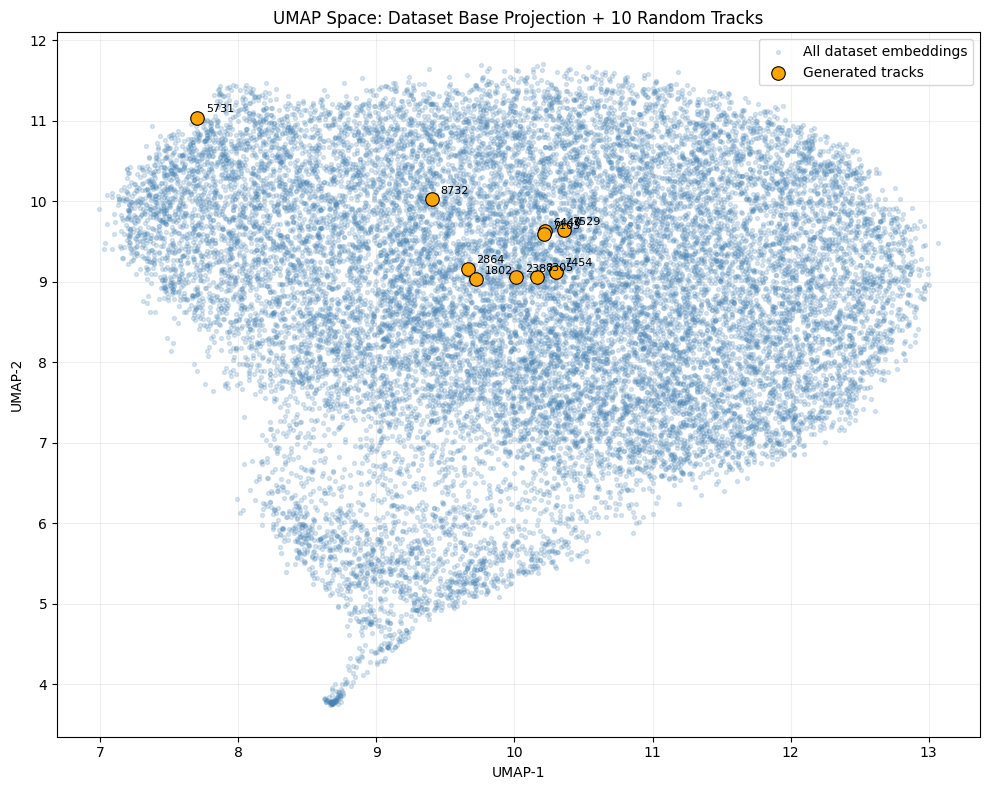

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from mapelite.evaluator import EvaluatorMetrics

evaluator = EvaluatorMetrics.load_pretrained(EMBEDDING_MODEL_PATH)

# Base projection of all embeddings from the dataset
base_projection = umap_model.transform(_embeddings)

# Compute metric embeddings for the 10 generated tracks and project them into UMAP space
track_embeddings = []
track_seeds = []

for item in tracks_results:
    item_np = np.array(item["embedding_data"])
    embedding = evaluator.measure_from_metrics(item_np)
    embedding = np.asarray(embedding).reshape(1, -1)
    track_embeddings.append(embedding[0])
    track_seeds.append(item["seed"])

if len(track_embeddings) == 0:
    raise ValueError("No valid track embeddings were generated.")

track_embeddings = np.asarray(track_embeddings)
tracks_projection = umap_model.transform(track_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(
    base_projection[:, 0],
    base_projection[:, 1],
    s=8,
    alpha=0.2,
    c="steelblue",
    label="All dataset embeddings",
)
plt.scatter(
    tracks_projection[:, 0],
    tracks_projection[:, 1],
    s=95,
    c="orange",
    edgecolors="black",
    linewidths=0.8,
    label="Generated tracks",
)

for i, seed in enumerate(track_seeds):
    plt.annotate(
        str(seed),
        (tracks_projection[i, 0], tracks_projection[i, 1]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
    )

plt.title("UMAP Space: Dataset Base Projection + 10 Random Tracks")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Rolled 10% -> shift=15
Rolled 25% -> shift=37
Rolled 50% -> shift=75
Rolled 75% -> shift=112
Rolled 90% -> shift=135


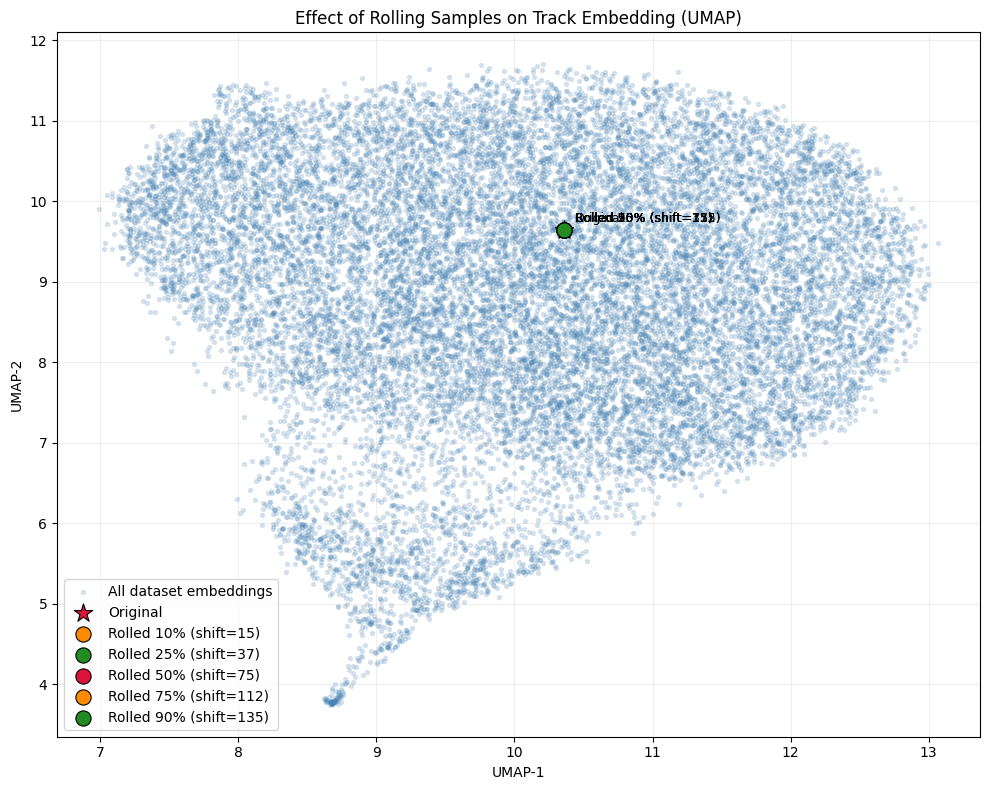

In [ ]:
def roll_samples_by_percent(embedding_data, percent=0.25):
    if not 0 <= percent <= 1:
        raise ValueError("percent must be between 0 and 1")

    num_samples = embedding_data.shape[0]
    shift = int(num_samples * percent)
    return np.roll(embedding_data, shift=shift, axis=0), shift

# Take the first generated track, roll its samples by each percent, then compare in UMAP space.
if len(tracks_results) == 0:
    raise ValueError("tracks_results is empty. Run the generation/evaluation cell first.")

original_embedding = np.array(tracks_results[0]["embedding_data"])
percents = [0.10, 0.25, 0.50, 0.75, 0.90]

original_metrics = evaluator.measure_from_metrics(original_embedding)
original_emb = np.asarray(original_metrics).reshape(1, -1)

comparison_embeddings = [original_emb[0]]
labels = ["Original"]

for percent in percents:
    rolled_data, shift = roll_samples_by_percent(original_embedding, percent)
    rolled_metrics = evaluator.measure_from_metrics(rolled_data)
    rolled_emb = np.asarray(rolled_metrics).reshape(1, -1)
    comparison_embeddings.append(rolled_emb[0])
    labels.append(f"Rolled {int(percent * 100)}% (shift={shift})")
    print(f"Rolled {int(percent * 100)}% -> shift={shift}")

comparison_embs = np.asarray(comparison_embeddings)
comparison_proj = umap_model.transform(comparison_embs)

plt.figure(figsize=(10, 8))
plt.scatter(
    base_projection[:, 0],
    base_projection[:, 1],
    s=8,
    alpha=0.18,
    c="steelblue",
    label="All dataset embeddings",
)

colors = ["crimson", "darkorange", "forestgreen"]
for i, label in enumerate(labels):
    marker = "*" if i == 0 else "o"
    size = 190 if i == 0 else 120
    plt.scatter(
        comparison_proj[i, 0],
        comparison_proj[i, 1],
        s=size,
        c=colors[i % len(colors)],
        edgecolors="black",
        linewidths=0.8,
        marker=marker,
        label=label,
    )
    plt.annotate(
        label,
        (comparison_proj[i, 0], comparison_proj[i, 1]),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=9,
    )

plt.title("Effect of Rolling Samples on Track Embedding (UMAP) for track seed " + str(tracks_results[0]["seed"]))
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

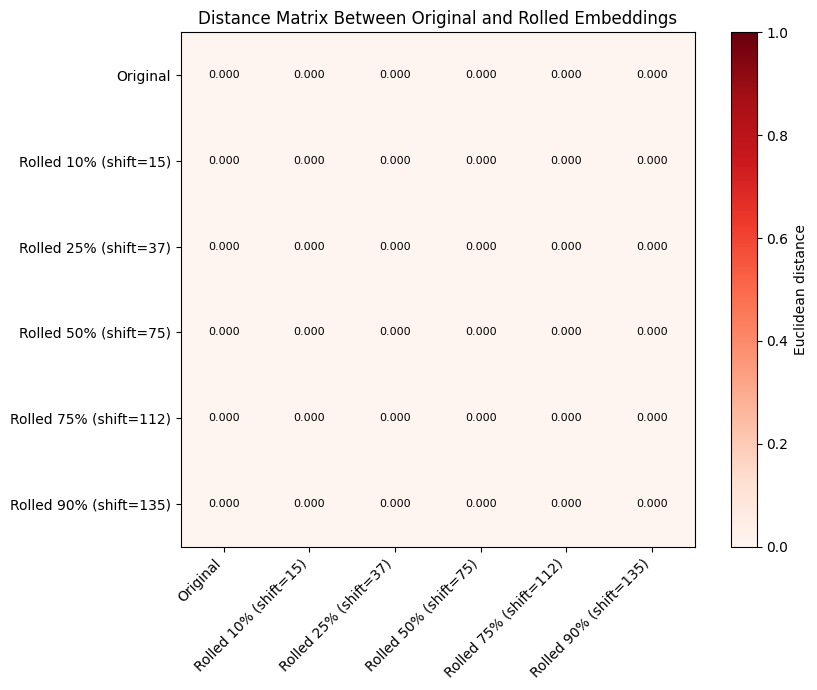

Pairwise Euclidean distances between embeddings:
Original vs Rolled 10% (shift=15): 0.0000013759
Original vs Rolled 25% (shift=37): 0.0000011096
Original vs Rolled 50% (shift=75): 0.0000012260
Original vs Rolled 75% (shift=112): 0.0000011862
Original vs Rolled 90% (shift=135): 0.0000012056
Rolled 10% (shift=15) vs Rolled 25% (shift=37): 0.0000013823
Rolled 10% (shift=15) vs Rolled 50% (shift=75): 0.0000011866
Rolled 10% (shift=15) vs Rolled 75% (shift=112): 0.0000011966
Rolled 10% (shift=15) vs Rolled 90% (shift=135): 0.0000010918
Rolled 25% (shift=37) vs Rolled 50% (shift=75): 0.0000013728
Rolled 25% (shift=37) vs Rolled 75% (shift=112): 0.0000012190
Rolled 25% (shift=37) vs Rolled 90% (shift=135): 0.0000016313
Rolled 50% (shift=75) vs Rolled 75% (shift=112): 0.0000011646
Rolled 50% (shift=75) vs Rolled 90% (shift=135): 0.0000010812
Rolled 75% (shift=112) vs Rolled 90% (shift=135): 0.0000012981


In [ ]:

embedding_vectors = np.asarray(comparison_embs)
labels_for_plot = list(labels)

# Pairwise Euclidean distances between embedding vectors
distance_matrix = np.linalg.norm(
    embedding_vectors[:, None, :] - embedding_vectors[None, :, :],
    axis=2,
)

max_value = float(np.max(distance_matrix))
colorbar_vmax = max(1.0, max_value)

plt.figure(figsize=(9, 7))
im = plt.imshow(distance_matrix, cmap="Reds", vmin=0.0, vmax=colorbar_vmax)
plt.colorbar(im, label="Euclidean distance")
plt.title("Distance Matrix Between Original and Rolled Embeddings")
plt.xticks(range(len(labels_for_plot)), labels_for_plot, rotation=45, ha="right")
plt.yticks(range(len(labels_for_plot)), labels_for_plot)

for i in range(distance_matrix.shape[0]):
    for j in range(distance_matrix.shape[1]):
        value = distance_matrix[i, j]
        text_color = "white" if value > colorbar_vmax * 0.5 else "black"
        plt.text(j, i, f"{value:.3f}", ha="center", va="center", color=text_color, fontsize=8)

plt.tight_layout()
plt.show()

# print the distances
print("Pairwise Euclidean distances between embeddings:")
for i in range(distance_matrix.shape[0]):
    for j in range(i + 1, distance_matrix.shape[1]):
        print(f"{labels_for_plot[i]} vs {labels_for_plot[j]}: {distance_matrix[i, j]:.10f}") 